#  Part 1: Damage Detection Model - Training & Saving

## Purpose
Train a ResNet-18 model to detect vehicle damage types.

## Output
- `damage_model.pth` - Trained model weights
- `damage_labels.json` - Class mappings
- `training_history.pkl` - Training metrics

---

In [1]:
# ============================================
# IMPORTS
# ============================================

print("="*80)
print(" LOADING LIBRARIES")
print("="*80)

import os
import json
import pickle
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

print("\n Libraries loaded!")
print(f"   PyTorch: {torch.__version__}")
print(f"   Device: {'CUDA GPU' if torch.cuda.is_available() else 'CPU'}")
print("="*80)

 LOADING LIBRARIES

 Libraries loaded!
   PyTorch: 2.9.1
   Device: CPU


In [10]:
# ============================================
# CONFIGURATION
# ============================================

print("\n" + "="*80)
print("  CONFIGURATION")
print("="*80)

# Paths
DATA_DIR = Path('damage_vehicles/CAR')
TRAIN_JSON = DATA_DIR / 'annotations/instances_train2017.json'
VAL_JSON = DATA_DIR / 'annotations/instances_val2017.json'
TRAIN_IMG_DIR = DATA_DIR / 'train2017'
VAL_IMG_DIR = DATA_DIR / 'val2017'

# Output directory
OUTPUT_DIR = Path('models')
OUTPUT_DIR.mkdir(exist_ok=True)

# Model paths
DAMAGE_MODEL_PATH = OUTPUT_DIR / 'damage_model.pth'
DAMAGE_LABELS_PATH = OUTPUT_DIR / 'damage_labels.json'
HISTORY_PATH = OUTPUT_DIR / 'damage_training_history.pkl'

# Hyperparameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 0.001
DAMAGE_THRESHOLD = 0.5

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\n Data: {DATA_DIR}")
print(f" Output: {OUTPUT_DIR}")
print(f" Image size: {IMG_SIZE}")
print(f" Batch size: {BATCH_SIZE}")
print(f" Epochs: {NUM_EPOCHS}")
print(f" Device: {device}")
print("\n Configuration complete!")
print("="*80)


  CONFIGURATION

 Data: damage_vehicles/CAR
 Output: models
 Image size: (224, 224)
 Batch size: 32
 Epochs: 20
 Device: cpu

 Configuration complete!


In [11]:
# ============================================
# LOAD DATA
# ============================================

print("\n" + "="*80)
print(" LOADING DATA")
print("="*80)

# Load COCO annotations
with open(TRAIN_JSON, 'r') as f:
    train_data = json.load(f)

with open(VAL_JSON, 'r') as f:
    val_data = json.load(f)

# Extract damage categories
categories = {cat['id']: cat['name'] for cat in train_data['categories']}
num_classes = len(categories)

print(f"\n Training: {len(train_data['images'])} images")
print(f" Validation: {len(val_data['images'])} images")
print(f"\n Damage classes ({num_classes} total):")
for cat_id, name in sorted(categories.items()):
    print(f"   {cat_id}: {name}")

# Create mappings
class_to_idx = {name: idx-1 for idx, name in categories.items()}
idx_to_class = {idx-1: name for idx, name in categories.items()}

print("\n Data loaded!")
print("="*80)


 LOADING DATA

 Training: 2816 images
 Validation: 810 images

 Damage classes (6 total):
   1: dent
   2: scratch
   3: crack
   4: glass shatter
   5: lamp broken
   6: tire flat

 Data loaded!


In [12]:
# ============================================
# DATA PREPROCESSING
# ============================================

# Image transformations
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

print("\n Transforms defined")

# Dataset class
class CarDamageDataset(Dataset):
    def __init__(self, coco_data, img_dir, transform=None, class_to_idx=None):
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.num_classes = len(class_to_idx)
        self.images = coco_data['images']
        
        # Map annotations
        self.img_to_anns = defaultdict(list)
        for ann in coco_data['annotations']:
            self.img_to_anns[ann['image_id']].append(ann)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = self.img_dir / img_info['file_name']
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Get multi-label target
        target = torch.zeros(self.num_classes, dtype=torch.float32)
        anns = self.img_to_anns[img_info['id']]
        for ann in anns:
            cat_idx = self.class_to_idx[categories[ann['category_id']]]
            target[cat_idx] = 1.0
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

# Create datasets
train_dataset = CarDamageDataset(train_data, TRAIN_IMG_DIR, train_transform, class_to_idx)
val_dataset = CarDamageDataset(val_data, VAL_IMG_DIR, val_transform, class_to_idx)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n Training: {len(train_dataset)} images, {len(train_loader)} batches")
print(f" Validation: {len(val_dataset)} images, {len(val_loader)} batches")
print("\n Preprocessing complete!")
print("="*80)


 Transforms defined

 Training: 2816 images, 88 batches
 Validation: 810 images, 26 batches

 Preprocessing complete!


In [13]:
# ============================================
# MODEL DEFINITION
# ============================================

print("\n" + "="*80)
print(" MODEL DEFINITION")
print("="*80)

class DamageDetectionModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

model = DamageDetectionModel(num_classes=num_classes, pretrained=True)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"\n Model: ResNet18")
print(f"   Classes: {num_classes}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*80)


 MODEL DEFINITION

 Model: ResNet18
   Classes: 6
   Parameters: 11,309,382


In [14]:
# ============================================
# TRAINING
# ============================================

print("\n" + "="*80)
print("🎓 MODEL TRAINING")
print("="*80)

if DAMAGE_MODEL_PATH.exists():
    print("\n Model already exists!")
    print(f"   Path: {DAMAGE_MODEL_PATH}")
    print("\n💡 Delete the file to retrain, or skip to evaluation.")
    
    model.load_state_dict(torch.load(DAMAGE_MODEL_PATH, map_location=device))
    
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH, 'rb') as f:
            history = pickle.load(f)
        print(" Training history loaded")
    else:
        history = None
        
else:
    print("\n🎓 Training new model...\n")
    
    def train_epoch(model, loader, criterion, optimizer, device):
        model.train()
        running_loss = 0.0
        all_preds, all_targets = [], []
        
        for images, targets in tqdm(loader, desc='Training'):
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).cpu()
            all_preds.append(preds)
            all_targets.append(targets.cpu())
        
        epoch_loss = running_loss / len(loader)
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        accuracy = (all_preds == all_targets).float().mean().item()
        
        return epoch_loss, accuracy
    
    def validate_epoch(model, loader, criterion, device):
        model.eval()
        running_loss = 0.0
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for images, targets in tqdm(loader, desc='Validation'):
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                running_loss += loss.item()
                
                preds = (torch.sigmoid(outputs) > 0.5).cpu()
                all_preds.append(preds)
                all_targets.append(targets.cpu())
        
        epoch_loss = running_loss / len(loader)
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        accuracy = (all_preds == all_targets).float().mean().item()
        
        return epoch_loss, accuracy
    
    # Training loop
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 40)
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), DAMAGE_MODEL_PATH)
            print(f" Best model saved!")
    
    # Save history
    with open(HISTORY_PATH, 'wb') as f:
        pickle.dump(history, f)
    
    # Save labels
    with open(DAMAGE_LABELS_PATH, 'w') as f:
        json.dump({
            'class_to_idx': class_to_idx,
            'idx_to_class': idx_to_class,
            'num_classes': num_classes
        }, f, indent=2)
    
    print("\n" + "="*80)
    print(" TRAINING COMPLETE!")
    print("="*80)
    print(f"\n Saved files:")
    print(f"   • {DAMAGE_MODEL_PATH}")
    print(f"   • {DAMAGE_LABELS_PATH}")
    print(f"   • {HISTORY_PATH}")

print("\n🎯 Model ready for evaluation!")


🎓 MODEL TRAINING

🎓 Training new model...


Epoch 1/20
----------------------------------------


Validation: 100%|██████████| 26/26 [00:29<00:00,  1.12s/it]


Train Loss: 0.4030 | Train Acc: 0.8055
Val Loss: 0.5400 | Val Acc: 0.7556
 Best model saved!

Epoch 2/20
----------------------------------------


Validation: 100%|██████████| 26/26 [00:31<00:00,  1.20s/it]


Train Loss: 0.3567 | Train Acc: 0.8313
Val Loss: 0.4338 | Val Acc: 0.7938
 Best model saved!

Epoch 3/20
----------------------------------------


...

Train Loss: 0.2032 | Train Acc: 0.9165
Val Loss: 0.3007 | Val Acc: 0.8776

Epoch 19/20
----------------------------------------


Validation: 100%|██████████| 26/26 [00:28<00:00,  1.11s/it]


Train Loss: 0.1936 | Train Acc: 0.9206
Val Loss: 0.2923 | Val Acc: 0.8802

Epoch 20/20
----------------------------------------


Validation: 100%|██████████| 26/26 [00:30<00:00,  1.17s/it]

Train Loss: 0.1868 | Train Acc: 0.9238
Val Loss: 0.3181 | Val Acc: 0.8671

 TRAINING COMPLETE!

 Saved files:
   • models/damage_model.pth
   • models/damage_labels.json
   • models/damage_training_history.pkl

🎯 Model ready for evaluation!



 TRAINING CURVES


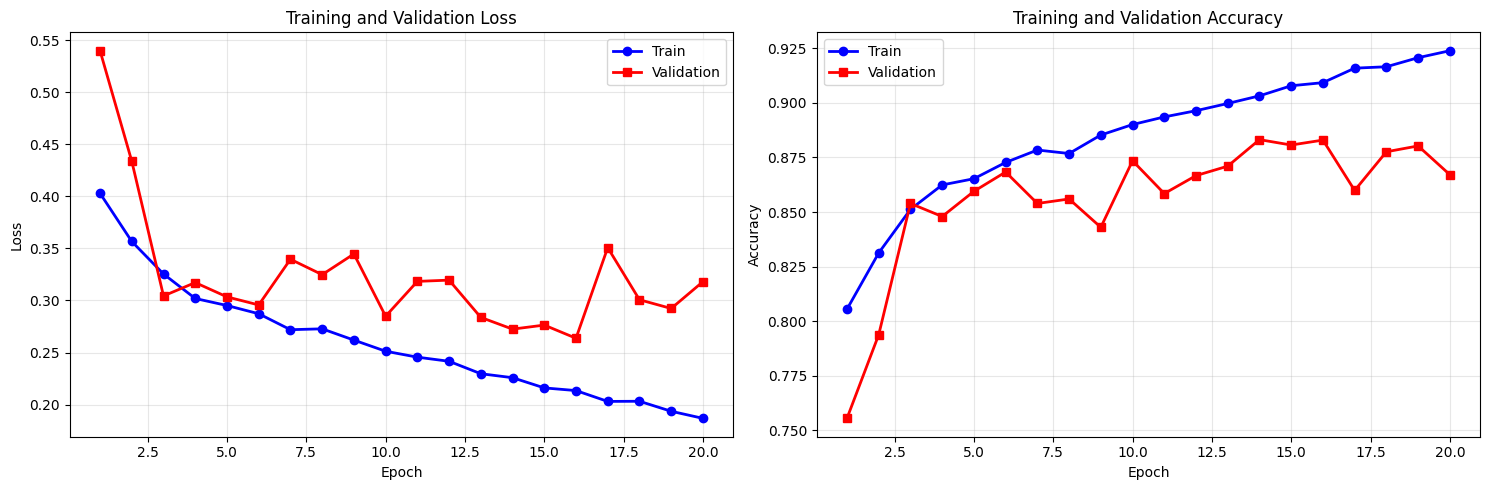


📊 Final Metrics:
   Train Loss: 0.1868
   Train Acc: 0.9238
   Val Loss: 0.3181
   Val Acc: 0.8671


In [15]:
# ============================================
# EVALUATION - TRAINING CURVES
# ============================================

if history:
    print("\n" + "="*80)
    print(" TRAINING CURVES")
    print("="*80)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', linewidth=2)
    axes[0].plot(epochs_range, history['val_loss'], 'r-s', label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train', linewidth=2)
    axes[1].plot(epochs_range, history['val_acc'], 'r-s', label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
    plt.show()
    
    print("\n📊 Final Metrics:")
    print(f"   Train Loss: {history['train_loss'][-1]:.4f}")
    print(f"   Train Acc: {history['train_acc'][-1]:.4f}")
    print(f"   Val Loss: {history['val_loss'][-1]:.4f}")
    print(f"   Val Acc: {history['val_acc'][-1]:.4f}")
    print("="*80)

In [1]:
pip show scikit-learn


Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /opt/anaconda3/envs/myenv/lib/python3.11/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: category-encoders, imbalanced-learn, librosa, lime, pmdarima, pyannote.metrics, pyannote.pipeline, pytorch-metric-learning, rdt, sdmetrics, shap, tensorflow_privacy
Note: you may need to restart the kernel to use updated packages.


In [16]:
# ============================================
# EVALUATION - CLASSIFICATION REPORT
# ============================================

print("\n" + "="*80)
print("📋 CLASSIFICATION REPORT")
print("="*80)

# Get predictions
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > DAMAGE_THRESHOLD).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.numpy())

all_preds = np.vstack(all_preds)
all_targets = np.vstack(all_targets)

# Per-class metrics
print("\nPer-Class Metrics:\n")
for class_idx in range(num_classes):
    class_name = idx_to_class[class_idx]
    y_true = all_targets[:, class_idx]
    y_pred = all_preds[:, class_idx]
    
    if y_true.sum() > 0:
        f1 = f1_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        
        print(f"{class_name:20s} F1: {f1:.3f}  Precision: {prec:.3f}  Recall: {rec:.3f}")

# Overall metrics
hamming_acc = (all_preds == all_targets).mean()
macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

print("\n" + "-"*80)
print(f"Hamming Accuracy: {hamming_acc:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print("="*80)

print("\n DAMAGE DETECTION MODEL READY FOR DEPLOYMENT!")
print(f"\n Model saved at: {DAMAGE_MODEL_PATH}")


📋 CLASSIFICATION REPORT


Evaluating: 100%|██████████| 26/26 [00:31<00:00,  1.22s/it]


Per-Class Metrics:

dent                 F1: 0.755  Precision: 0.736  Recall: 0.776
scratch              F1: 0.738  Precision: 0.798  Recall: 0.687
crack                F1: 0.418  Precision: 0.633  Recall: 0.311
glass shatter        F1: 0.913  Precision: 0.967  Recall: 0.866
lamp broken          F1: 0.687  Precision: 0.599  Recall: 0.806
tire flat            F1: 0.794  Precision: 0.683  Recall: 0.949

--------------------------------------------------------------------------------
Hamming Accuracy: 0.8671
Macro F1-Score: 0.7176

 DAMAGE DETECTION MODEL READY FOR DEPLOYMENT!

 Model saved at: models/damage_model.pth
